# Multi Linear Regression $\Delta\!$ MLat with Dipole Tilt and Vy

## Imports

In [10]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression # multilinear fit
from sklearn.metrics import mean_squared_error # needed for confidence intervals
import pandas as pd
from scipy.stats import t, iqr # students t test for confidence intervals and interquartile range

# Loading Dataset
Loading Onset file and created $\Delta\!$ MLat column

In [11]:
Onsets= pd.read_csv('../Data/Mediated_Onsets.csv', parse_dates=['Date_NH'])
Onsets= Onsets[Onsets.flag==1][['Date_NH', 'Frey_MLT', 'Frey_MLAT', 'MLAT_SH']]
Onsets.loc[Onsets.Frey_MLT<12, 'Frey_MLT']+=24
Onsets['DMLAT']=Onsets['MLAT_SH']-Onsets['Frey_MLAT']

## Rounding Time
Rounding the NH image time to the nearest minute

In [12]:
diff= Onsets.Date_NH-Onsets.Date_NH.values.astype('datetime64[m]')
delta= np.zeros(diff.shape).astype('timedelta64[m]')
delta[diff.values>=np.timedelta64(30, 's')]=np.timedelta64(1, 'm')
Onsets['Date_UTC']=Onsets.Date_NH.values.astype('datetime64[m]').astype('datetime64[ns]')+delta

## Loading Omni
Load the omni data

In [13]:
omni= pd.read_hdf('../Data/omni_data.hdf5', key='omni_window_2h_20')
omni['Date_UTC']= omni.index.values
omni.index= list(range(len(omni)))

## Merging Omni and Onset dataframes using the time column

In [14]:
Onsets= Onsets.merge(omni, on='Date_UTC')

## Handling Outliers
We use 1.5 times the interquartile range over and under the upper and lower quartiles to define outliers and exclude them from feature importance

In [15]:
# Outliers
upper_lim= Onsets.DMLAT<np.quantile(Onsets.DMLAT, .75)+iqr(Onsets.DMLAT)*1.5
lower_lim= Onsets.DMLAT>np.quantile(Onsets.DMLAT, .25)-iqr(Onsets.DMLAT)*1.5
rm_out= upper_lim&lower_lim

## Removing Missing Solar Wind Data

In [16]:
Onsets= Onsets[Onsets.Vy.notnull()]

## Selecting Columns and Excluding Outliers

In [17]:
X1= Onsets[rm_out].Vy.values
X2= Onsets[rm_out].Dipole_Tilt.values
Y= Onsets[rm_out].DMLAT.values
X = np.column_stack((X1, X2))


/tmp/ipykernel_1001649/4239892053.py:1: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  X1= Onsets[rm_out].Vy.values
/tmp/ipykernel_1001649/4239892053.py:2: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  X2= Onsets[rm_out].Dipole_Tilt.values
/tmp/ipykernel_1001649/4239892053.py:3: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  Y= Onsets[rm_out].DMLAT.values


## Performing Multi Linear Fit

In [18]:
model = LinearRegression()
model.fit(X, Y)

LinearRegression()

## Calculating Confidence Intervals

In [19]:
# Degrees of freedom
n, p = X.shape
dof = n - p - 1  # Degrees of freedom for t-distribution

# Compute Mean Squared Error (MSE)
Y_pred = model.predict(X)
residuals = Y - Y_pred
mse = np.mean(residuals**2)  # Mean Squared Error

# Compute standard errors for coefficients
X_design = np.column_stack([np.ones(n), X])  # Add intercept term
var_beta = mse * np.linalg.inv(X_design.T @ X_design)  # Variance-Covariance matrix
se_beta = np.sqrt(np.diag(var_beta))  # Standard errors for intercept & coefficients

# Critical t-value for 95% confidence interval
alpha = 0.1  # 90% CI
t_val = t.ppf(1 - alpha / 2, dof)

# Confidence intervals
conf_int = t_val * se_beta
intercept_conf = conf_int[0]
coef_conf = conf_int[1:]


## Generating Contour Plotting Data

In [20]:
x1_lim= -100, 100
x2_lim= -40, 40
# Create a grid of values for X1 and X2 for plotting
x1_range = np.linspace(*x1_lim, 100)
x2_range = np.linspace(*x2_lim, 100)
x1_grid, x2_grid = np.meshgrid(x1_range, x2_range)
# Predict Y values for the grid
y_pred_grid = model.intercept_ + model.coef_[0] * x1_grid + model.coef_[1] * x2_grid

## Creating Figure and Plotting Results

/tmp/ipykernel_1001649/285334992.py:13: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  ax.scatter(Onsets[~rm_out].Vy.values, Onsets[~rm_out].Dipole_Tilt.values, marker='o',
/tmp/ipykernel_1001649/285334992.py:13: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  ax.scatter(Onsets[~rm_out].Vy.values, Onsets[~rm_out].Dipole_Tilt.values, marker='o',


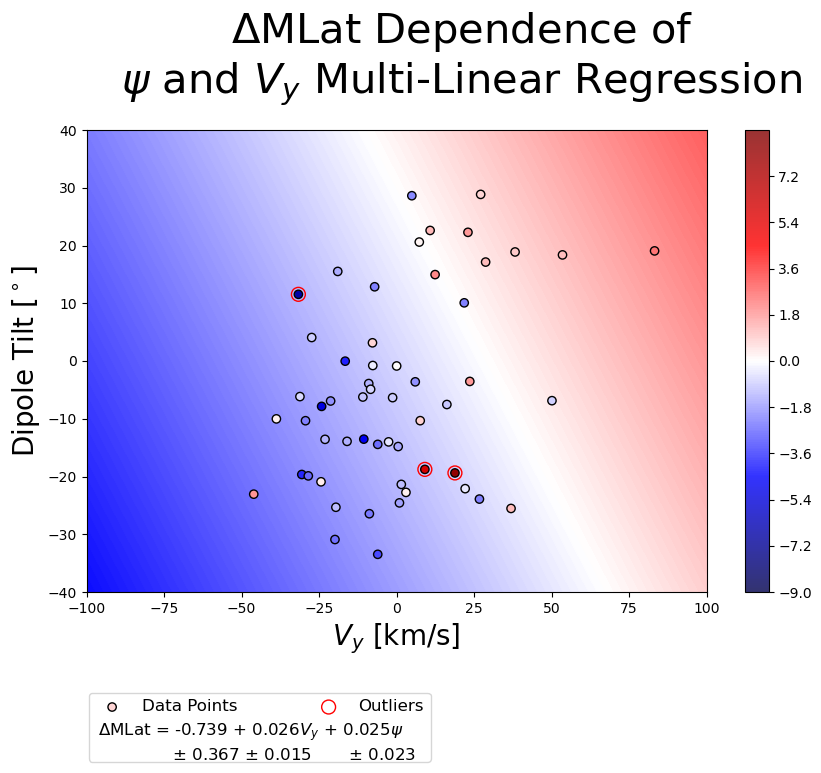

In [21]:
# Create Figure
fig= plt.figure(figsize=(10, 6))
ax = fig.add_subplot(111)
# Create Contour
contour = ax.contourf(x1_grid, x2_grid, y_pred_grid, alpha=0.8, cmap='seismic', vmin=-9, vmax=9,
                      levels= np.linspace(-9, 9, 10000))
cbar= fig.colorbar(contour)
# Scatter Data Points
ax.scatter(Onsets.Vy.values, Onsets.Dipole_Tilt.values, c=Onsets.DMLAT.values, cmap=contour.cmap, edgecolor='k', label='Data Points',
            vmin=contour.get_clim()[0], vmax=contour.get_clim()[1])  # Scatter plot of data
ax.scatter(0, 0, color='white', label='  '*13+'\n'+' '*13, alpha=0)

ax.scatter(Onsets[~rm_out].Vy.values, Onsets[~rm_out].Dipole_Tilt.values, marker='o',
           facecolors='none', edgecolors='r', label='Outliers',
            s=100)  # Scatter plot of data
intercept = model.intercept_
coef_x1 = model.coef_[0]
coef_x2 = model.coef_[1]

# Format the equation as a LaTeX string
equation = (
    r"$\Delta$MLat = {:.3f} + {:.3f}$V_y$ + {:.3f}$\psi$"
    .format(intercept, coef_x1, coef_x2)+'\n'+\
    ' '*14+r"$\pm$ {:.3f} $\pm$ {:.3f}       $\pm$ {:.3f}".format(*conf_int)
)
# Creeating Hidden Scatter to put equation in legend
# Set labels and limits
ax.set_xlabel(r'$V_y$ [km/s]', size=20)
ax.set_ylabel(r'Dipole Tilt [$^\circ$]', size=20)
ax.set_ylim(*x2_lim)
ax.set_xlim(*x1_lim)
fig.suptitle(r'$\Delta$MLat Dependence of'+'\n'+r'$\psi$ and $V_y$ Multi-Linear Regression', size=30, y=1.08)
fig.text(.136, -.17, equation, size=12)
leg=ax.legend(bbox_to_anchor=(-.01, -0.2), ncols=2, fontsize=12, loc='upper left')


## Adding Extra Axes Information

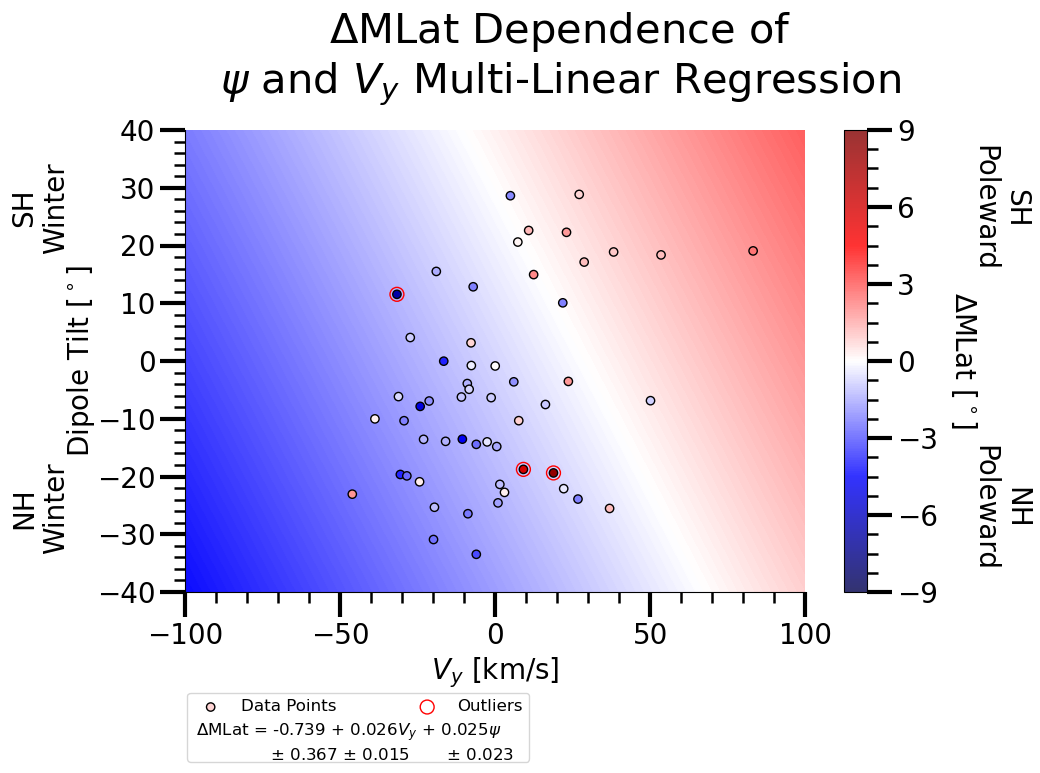

In [22]:
fig.text(-0.02, .25, 'NH\nWinter', rotation=90, va='center', ha='center', size=20)
fig.text(-0.02, .75, 'SH\nWinter', rotation=90, va='center', ha='center', size=20)

fig.text(.94, .25, 'NH\nPoleward', rotation=270, va='center', ha='center', size=20)
fig.text(.94, .75, 'SH\nPoleward', rotation=270, va='center', ha='center', size=20)
cbar.set_label(r'$\Delta$MLat '+ r'[$^\circ$]', rotation=270, labelpad=30, size=20)
cbar.set_ticks(np.arange(-9, 10, 3))
ax.set_ylabel('Dipole Tilt '+ r'[$^\circ$]', size=20, labelpad=0)
for ax_ in (ax, cbar.ax):
    ax_.tick_params(axis='both', which='major', labelsize=20, length=18, width=3)
    ax_.tick_params(axis='both', which='minor', length=8, width=1.8)
# removing unneeded splines
for ax_ in (ax, cbar.ax):
    ax_.spines['top'].set_visible(False)
    ax_.minorticks_on()
ax.spines['right'].set_visible(False)
fig

## Save Fits

In [23]:
fit= {'m1': coef_x1, 'm2':coef_x2, 'c':intercept}
fits={'MLAT_Dip_Vy':fit}
import os
if os.path.isfile('./fitting_params.txt'):
    file= open('./fitting_params.txt', mode='r')
    fits.update(eval(file.read()))
    file.close()



file= open('./fitting_params.txt', mode='w')

file.write(str(fits))
file.close()